# SigFormer benchmark

On-the-fly benchmark demonstration followed by CLI batch submission/checklist. All methods use one runner dictionary and one common benchmark data generator.

The notebook is intentionally verbose: configuration, inference, visualization, and saving are kept in separate cells so that a user can inspect or rerun each stage independently.

In [1]:
from __future__ import annotations

import datetime as _dt
import os, re, json, logging, math, shutil, subprocess, sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import SigFormer
from SigFormer.scripts import s04_Util_apply as analysis
from SigFormer.scripts.s06_wrapper import (
    CLASS_wrapper_MuSiCal,
    CLASS_wrapper_SigFormer,
    CLASS_wrapper_SigLASSO,
    CLASS_wrapper_SigProfilerAssignment,
    CLASS_wrapper_sig_tool_lib,
    CLASS_wrapper_sigfit,
)

MASTER_DIR = Path.cwd().resolve()
RESOURCE_DIR = Path(SigFormer.RESOURCE_DIR)

from SigFormer.scripts import s07_bench_helper as bench


In [2]:
%matplotlib inline

# Runtime state is configured explicitly in the notebook. Importing SigFormer does not
# mutate matplotlib, logging, warnings, random seeds, or torch thread settings.
os.environ.setdefault("PYTHONHASHSEED", "717")
torch.set_num_threads(int(os.environ.get("SIGFORMER_NUM_THREADS", "8")))

import logging, warnings
logging.disable(logging.INFO)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 150)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})


In [3]:
# Reproducible benchmark bank and output folders.

BASE_SEED = 19970717
SCRIPTS_DIR = Path(SigFormer.__file__).resolve().parent / "scripts"
DATE_TAG = _dt.datetime.now().strftime('%Y%m%d')
NOTEBOOK_ROOT = analysis.ensure_dir(MASTER_DIR / f'benchmark_{DATE_TAG}_notebook')
COSMIC_PATH = RESOURCE_DIR / 'COSMIC_v3.4_SBS_GRCh38.txt'
BANK_CACHE = NOTEBOOK_ROOT / '_cache/refbank_COSMIC_v3.4_seed19970717_nmock1000.pkl'
TMP_ROOT = analysis.ensure_dir(NOTEBOOK_ROOT / '_tmp')
bank, M_bank = bench.load_or_build_bank(cosmic_path=COSMIC_PATH, cosmic_version='v3.4', n_mock=1000, random_state=BASE_SEED, cache_path=BANK_CACHE, verbose=True)


[2026-08-12 03:03:33] Building reference bank: COSMIC=v3.4, n_mock=1000, seed=19970717
[mock] accepted 100/1000 after 122 trials
[mock] accepted 200/1000 after 238 trials
[mock] accepted 300/1000 after 348 trials
[mock] accepted 400/1000 after 472 trials
[mock] accepted 500/1000 after 596 trials
[mock] accepted 600/1000 after 739 trials
[mock] accepted 700/1000 after 869 trials
[mock] accepted 800/1000 after 989 trials
[mock] accepted 900/1000 after 1111 trials
[mock] accepted 1000/1000 after 1241 trials
[2026-08-12 03:03:34] Built bank: n_ref=1086, n_context=96
[2026-08-12 03:03:34] Saved reference bank cache: /storage/zong/home/u244338/04_Mutation/m05_Sigformer/m20_4/try_02/test_1/SigFormer_GitHub/benchmark_20260812_notebook/_cache/refbank_COSMIC_v3.4_seed19970717_nmock1000.pkl


In [9]:
# Every tunable wrapper parameter is visible here.

R_ENV = "SgF"
PATH_model = RESOURCE_DIR / 'sigformer_v9_epoch_1600.pt'
PARAM_REFINE = {'hard_composition': 0.005, 'hard_count': 3, 'prior_strength': 12.0, 'max_rescue': 2,
                'candidate_top_k': 6, 'max_l1_change': 0.20, 'max_ood_change': 0.15, 'max_ood_increase': 0.005,
                'rescue_min_composition': 0.01, 'n_channel_folds': 4, 'normalized_effective_depth': 1000, 'random_state': 717, 'version': None,}
PARAM_SgF = dict(PATH_model=str(PATH_model), epoch=None, device=None, simplex='softmax', strict=False, refine=True, refinement_kwargs=PARAM_REFINE)
PARAM_Mus = dict(method='likelihood_bidirectional', thresh=0.001)
PARAM_SPA = dict(PATH_tmp=None, hg_ver='GRCh38', cos_ver=3.4)
PARAM_sft = dict(conda_env=R_ENV, work_dir=None, fail_soft=False, iter=1400, warmup=None, chains=3, cores=1, seed=19970717)
PARAM_sLS = dict(conda_env=R_ENV, work_dir=None, fail_soft=False, conf=0.1, adaptive=True, gamma=1, alpha_min=400, iter_max=None, sd_multiplier=1.0, elastic_net=False, normalize='none',)
PARAM_stl = dict(conda_env=R_ENV, work_dir=None, nmuts_threshold=300, pvalue_threshold=0.15, pvalue_method='normErrorSAD', nmuts_method='residualSSD', fail_soft=False,)
TAG_TO_NAME = {'SgF_raw': 'SigFormer raw',
                   'SgF': 'SigFormer',
                   'Mus': 'MuSiCal',
                   'SPA': 'SigProfilerAssignment',
                   'sft': 'sigfit',
                   'sLS': 'sigLASSO',
                   'stl': 'signature.tools.lib',}
SIG_COLORS = analysis.DEFAULT_SIGNATURE_COLORS.copy()
METHOD_COLORS = analysis.METHOD_COLORS.copy()

In [ ]:
# Build one runner dictionary. SigFormer raw/refined share one loaded checkpoint.
model_SgF = CLASS_wrapper_SigFormer(**PARAM_SgF)

DICT_runner = {"SgF_raw":model_SgF.predict_raw,
                   "SgF":model_SgF,
                   "Mus":CLASS_wrapper_MuSiCal(**PARAM_Mus),
                   "SPA":CLASS_wrapper_SigProfilerAssignment(**PARAM_SPA, **PARAM_SPA_KWARGS),
                   "sft":CLASS_wrapper_sigfit(**PARAM_sft),
                   "sLS":CLASS_wrapper_SigLASSO(**PARAM_sLS),
                   "stl":CLASS_wrapper_sig_tool_lib(**PARAM_stl),}

display(pd.Series({tag: TAG_TO_NAME[tag] for tag in DICT_runner}, name="full_name"))


---

## 1. no_OOC

Each subsection has exactly four working cells: configuration, on-the-fly generation + inference, visualization, and result saving.

In [11]:
# Configure this benchmark condition.
cfg_no_OOC = bench.MAKE_config_batch(mode='no_OOC', BSize=12, REF_size={'COSMIC': 80, 'MOCK': 20}, depth_bin='1000-4000', noise_bin='0.85-0.90', compo_bin=1.0, active_bin='1-3')
out_no_OOC = analysis.ensure_dir(NOTEBOOK_ROOT / 'no_OOC')

In [12]:
# Generate the synthetic batch and run every selected method through the common timing wrapper.

batch_no_OOC = bench.generate_benchmark_batch(bank, M_bank, cfg=cfg_no_OOC, mode='no_OOC', random_state=BASE_SEED, batch_id='no_OOC_demo')
mask_no_OOC = bench.ref_mask_from_benchmark(batch_no_OOC, full_reference=True)
results_no_OOC, timing_no_OOC = ({}, [])
for name, model in DICT_runner.items():
    bench.RUN_method_timed(name, model, batch_no_OOC, mask_no_OOC, results_no_OOC, timing_no_OOC, unit_label='no_OOC', verbose=True)
timing_no_OOC = pd.DataFrame(timing_no_OOC)


[2026-08-12 03:21:41] no_OOC | SigFormer raw start: n_samples=12
[2026-08-12 03:21:42] no_OOC | SigFormer raw done: 0.45s, 37.76s / 1000 samples
[2026-08-12 03:21:42] no_OOC | SigFormer start: n_samples=12
[2026-08-12 03:21:43] no_OOC | SigFormer done: 0.94s, 78.68s / 1000 samples
[2026-08-12 03:21:43] no_OOC | MuSiCal start: n_samples=12
[2026-08-12 03:21:47] no_OOC | MuSiCal done: 4.69s, 390.89s / 1000 samples
[2026-08-12 03:21:47] no_OOC | SigProfilerAssignment start: n_samples=12
[2026-08-12 03:22:00] no_OOC | SigProfilerAssignment done: 12.68s, 1056.53s / 1000 samples
[2026-08-12 03:22:00] no_OOC | sigfit start: n_samples=12
[2026-08-12 03:24:17] no_OOC | sigfit done: 113.86s, 9488.75s / 1000 samples
[2026-08-12 03:24:17] no_OOC | sigLASSO start: n_samples=12
[2026-08-12 03:24:37] no_OOC | sigLASSO done: 20.45s, 1703.85s / 1000 samples
[2026-08-12 03:24:37] no_OOC | signature.tools.lib start: n_samples=12
[2026-08-12 03:24:51] no_OOC | signature.tools.lib done: 13.22s, 1101.25s / 

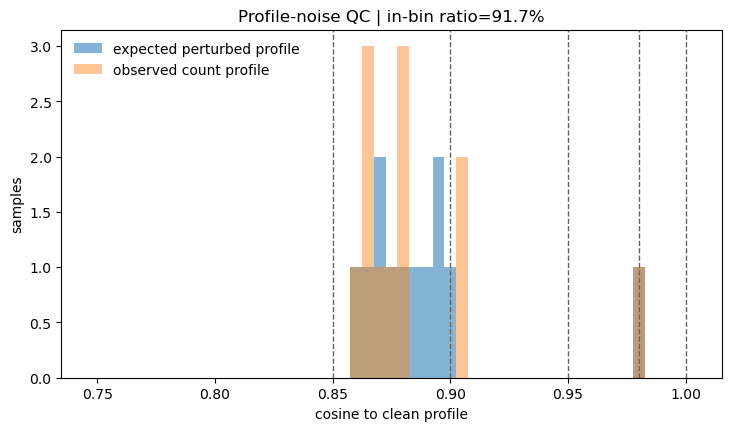

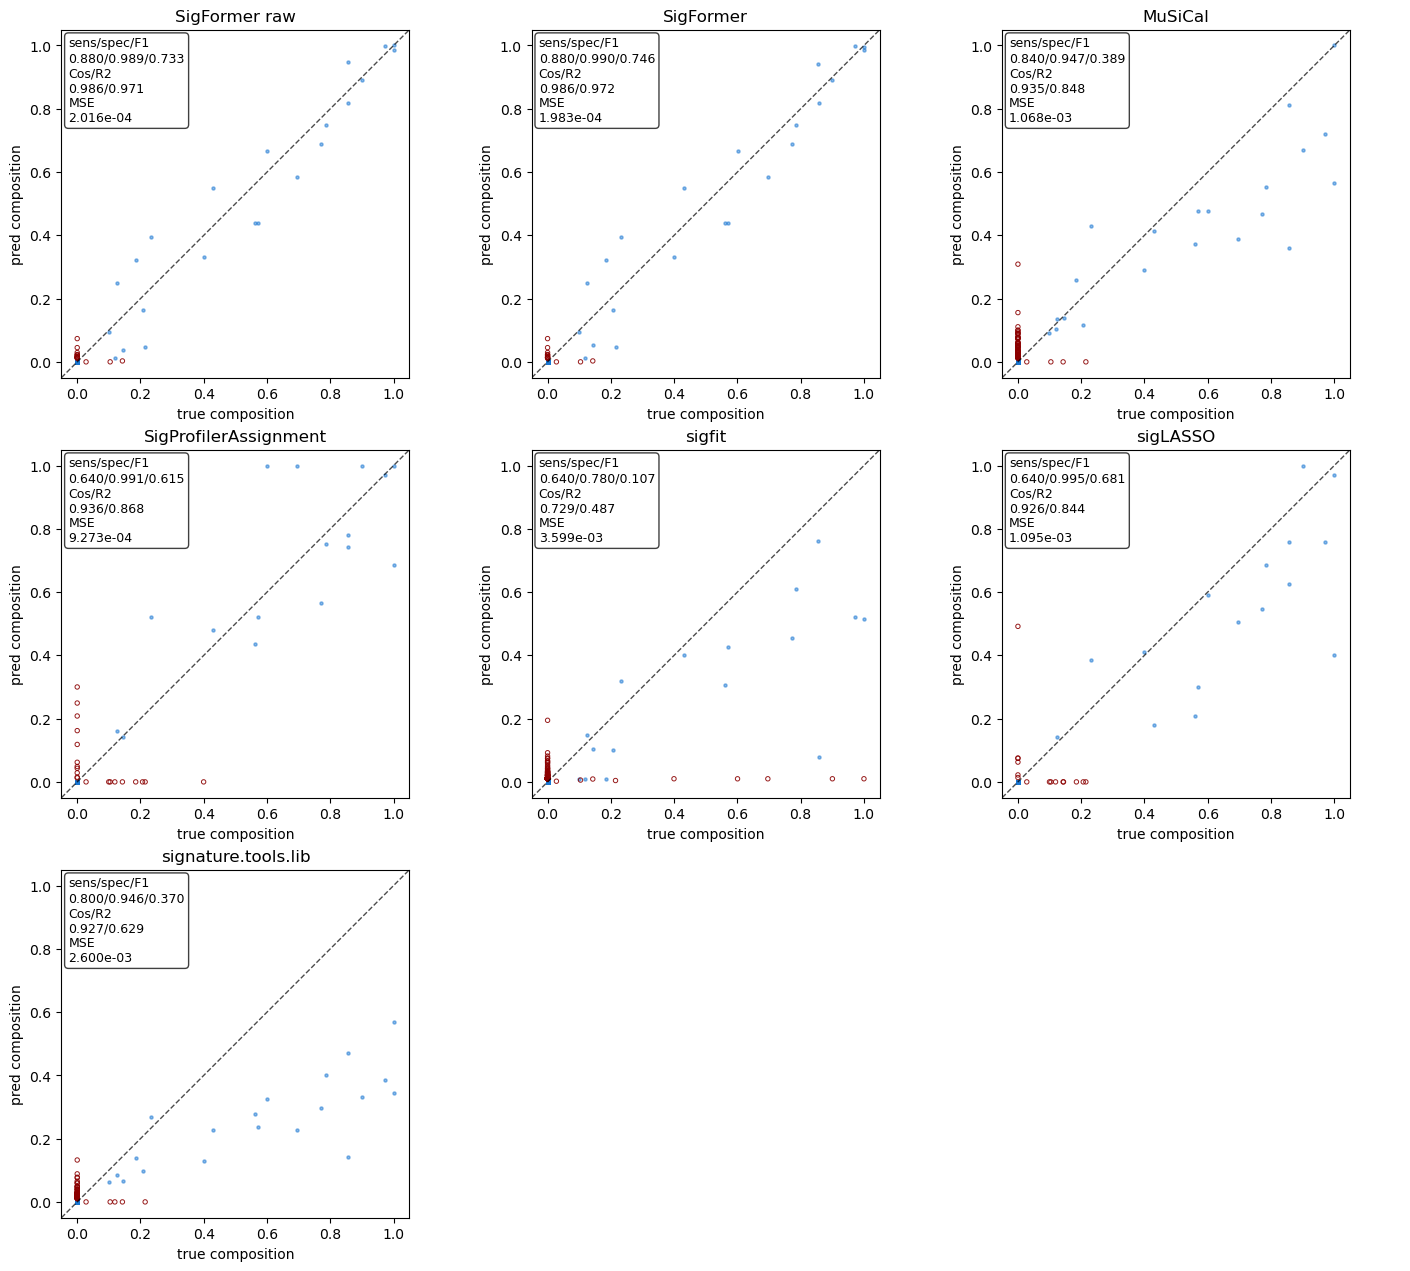

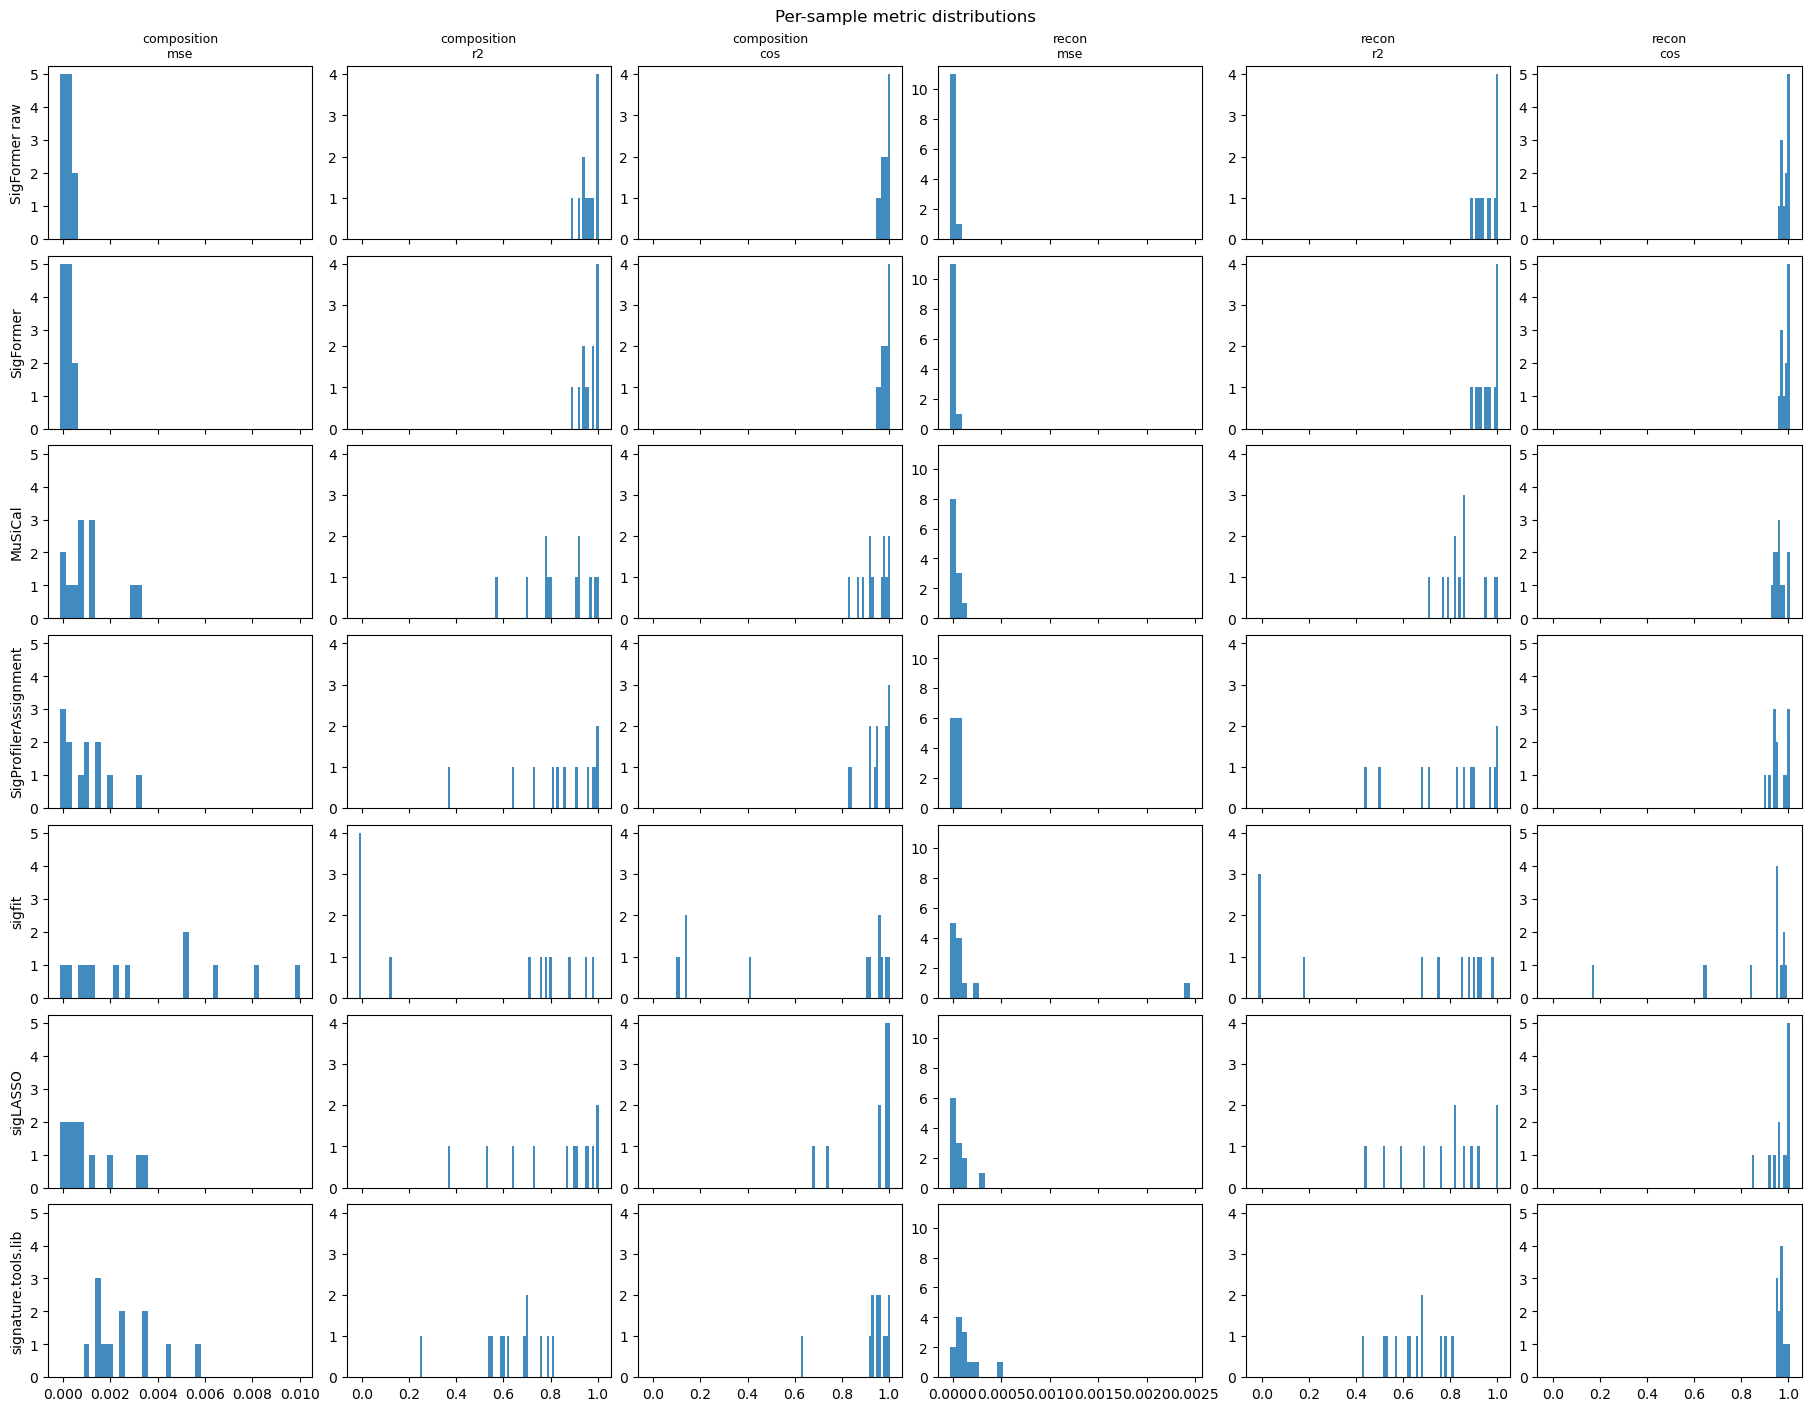

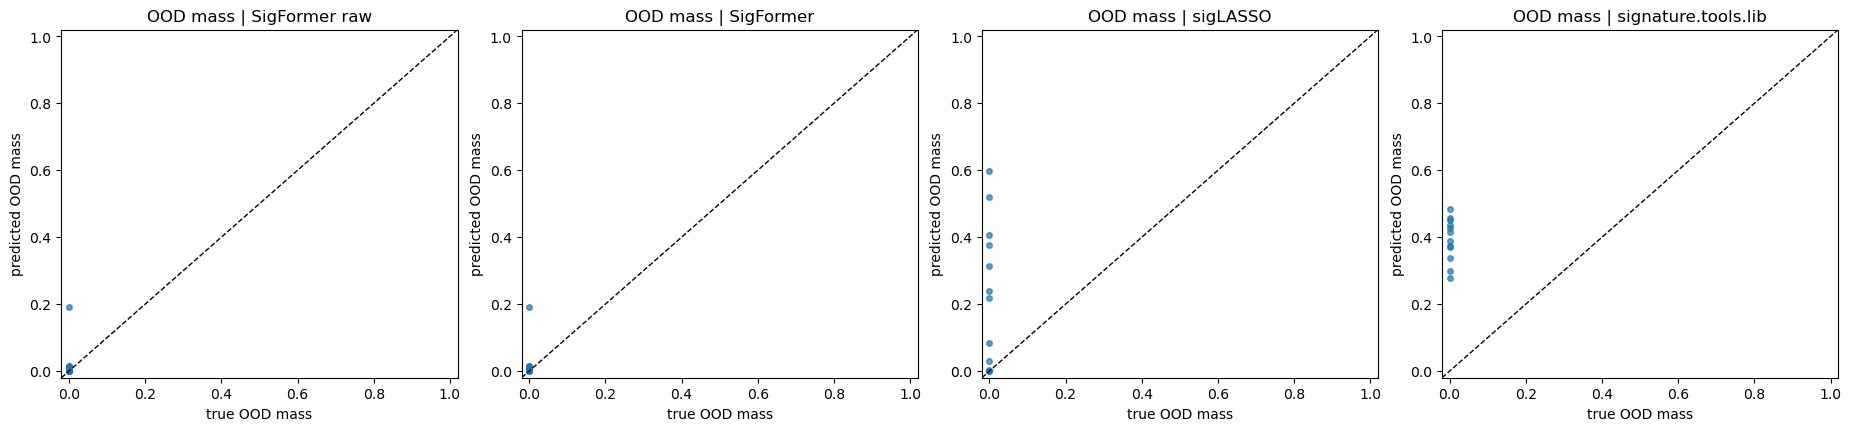

In [13]:
# Compute benchmark metrics and call each visualization function explicitly.

metrics_no_OOC, summary_no_OOC, compo_no_OOC, recon_no_OOC, ood_no_OOC, residual_no_OOC = bench.compute_benchmark_metrics(batch_no_OOC, results_no_OOC)
fig, ax = bench.plot_profile_noise_qc(batch_no_OOC)
plt.show() ; plt.close(fig)
fig, axes = bench.plot_compo_scatter_grid(batch_no_OOC['Y_compo_true'], compo_no_OOC, methods=list(DICT_runner))
plt.show() ; plt.close(fig)
fig, axes = bench.plot_metric_hist_grid(metrics_no_OOC, methods=list(DICT_runner))
plt.show() ; plt.close(fig)
true_ood_no_OOC = batch_no_OOC['Y_compo_true'].where(batch_no_OOC['Y__OOD__mask'].astype(bool), 0.0).sum(1)
fig, axes = bench.plot_ood_scatter_grid(true_ood_no_OOC, ood_no_OOC, methods=[m for m in bench.OOD_PRED_METHODS if m in DICT_runner])
plt.show() ; plt.close(fig)


In [14]:
# Persist numerical outputs after visualization.

bench.save_benchmark_outputs(batch_no_OOC, results_no_OOC, out_no_OOC, timing=timing_no_OOC, make_plots=False, prefix='benchmark')
summary_no_OOC.to_csv(out_no_OOC / 'summary_preview.tsv', sep='\t', index=False)


---

## 2. random_OOC

Each subsection has exactly four working cells: configuration, on-the-fly generation + inference, visualization, and result saving.

In [15]:
# Configure this benchmark condition.

cfg_random_OOC = bench.MAKE_config_batch(mode='random_OOC', BSize=12, REF_size={'COSMIC': 80, 'MOCK': 20}, depth_bin='1000-4000', noise_bin='0.90-0.95', compo_bin=1.0, active_bin='7-10', random_ood_frac=1.0, random_ood_max_compo=0.6, ood_min_compo=0.03)
out_random_OOC = analysis.ensure_dir(NOTEBOOK_ROOT / 'random_OOC')


In [16]:
# Generate the synthetic batch and run every selected method through the common timing wrapper.

batch_random_OOC = bench.generate_benchmark_batch(bank, M_bank, cfg=cfg_random_OOC, mode='random_OOC', random_state=BASE_SEED + 1, batch_id='random_OOC_demo')
mask_random_OOC = bench.ref_mask_from_benchmark(batch_random_OOC, full_reference=True)
results_random_OOC, timing_random_OOC = ({}, [])
for name, model in DICT_runner.items():
    bench.RUN_method_timed(name, model, batch_random_OOC, mask_random_OOC, results_random_OOC, timing_random_OOC, unit_label='random_OOC', verbose=True)
timing_random_OOC = pd.DataFrame(timing_random_OOC)


[2026-08-12 03:25:06] random_OOC | SigFormer raw start: n_samples=12
[2026-08-12 03:25:11] random_OOC | SigFormer raw done: 4.76s, 396.72s / 1000 samples
[2026-08-12 03:25:11] random_OOC | SigFormer start: n_samples=12
[2026-08-12 03:25:13] random_OOC | SigFormer done: 2.07s, 172.28s / 1000 samples
[2026-08-12 03:25:13] random_OOC | MuSiCal start: n_samples=12
[2026-08-12 03:25:23] random_OOC | MuSiCal done: 9.91s, 826.25s / 1000 samples
[2026-08-12 03:25:23] random_OOC | SigProfilerAssignment start: n_samples=12
[2026-08-12 03:25:36] random_OOC | SigProfilerAssignment done: 13.30s, 1108.11s / 1000 samples
[2026-08-12 03:25:36] random_OOC | sigfit start: n_samples=12
[2026-08-12 03:27:29] random_OOC | sigfit done: 101.30s, 8441.92s / 1000 samples
[2026-08-12 03:27:29] random_OOC | sigLASSO start: n_samples=12
[2026-08-12 03:28:08] random_OOC | sigLASSO done: 38.92s, 3243.45s / 1000 samples
[2026-08-12 03:28:08] random_OOC | signature.tools.lib start: n_samples=12
[2026-08-12 03:28:21] 

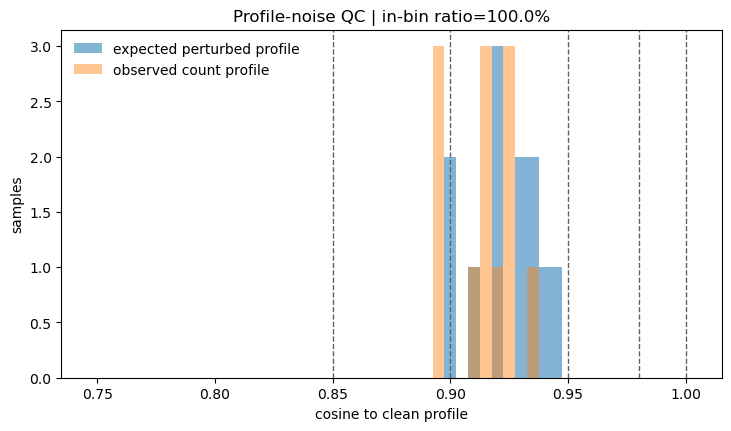

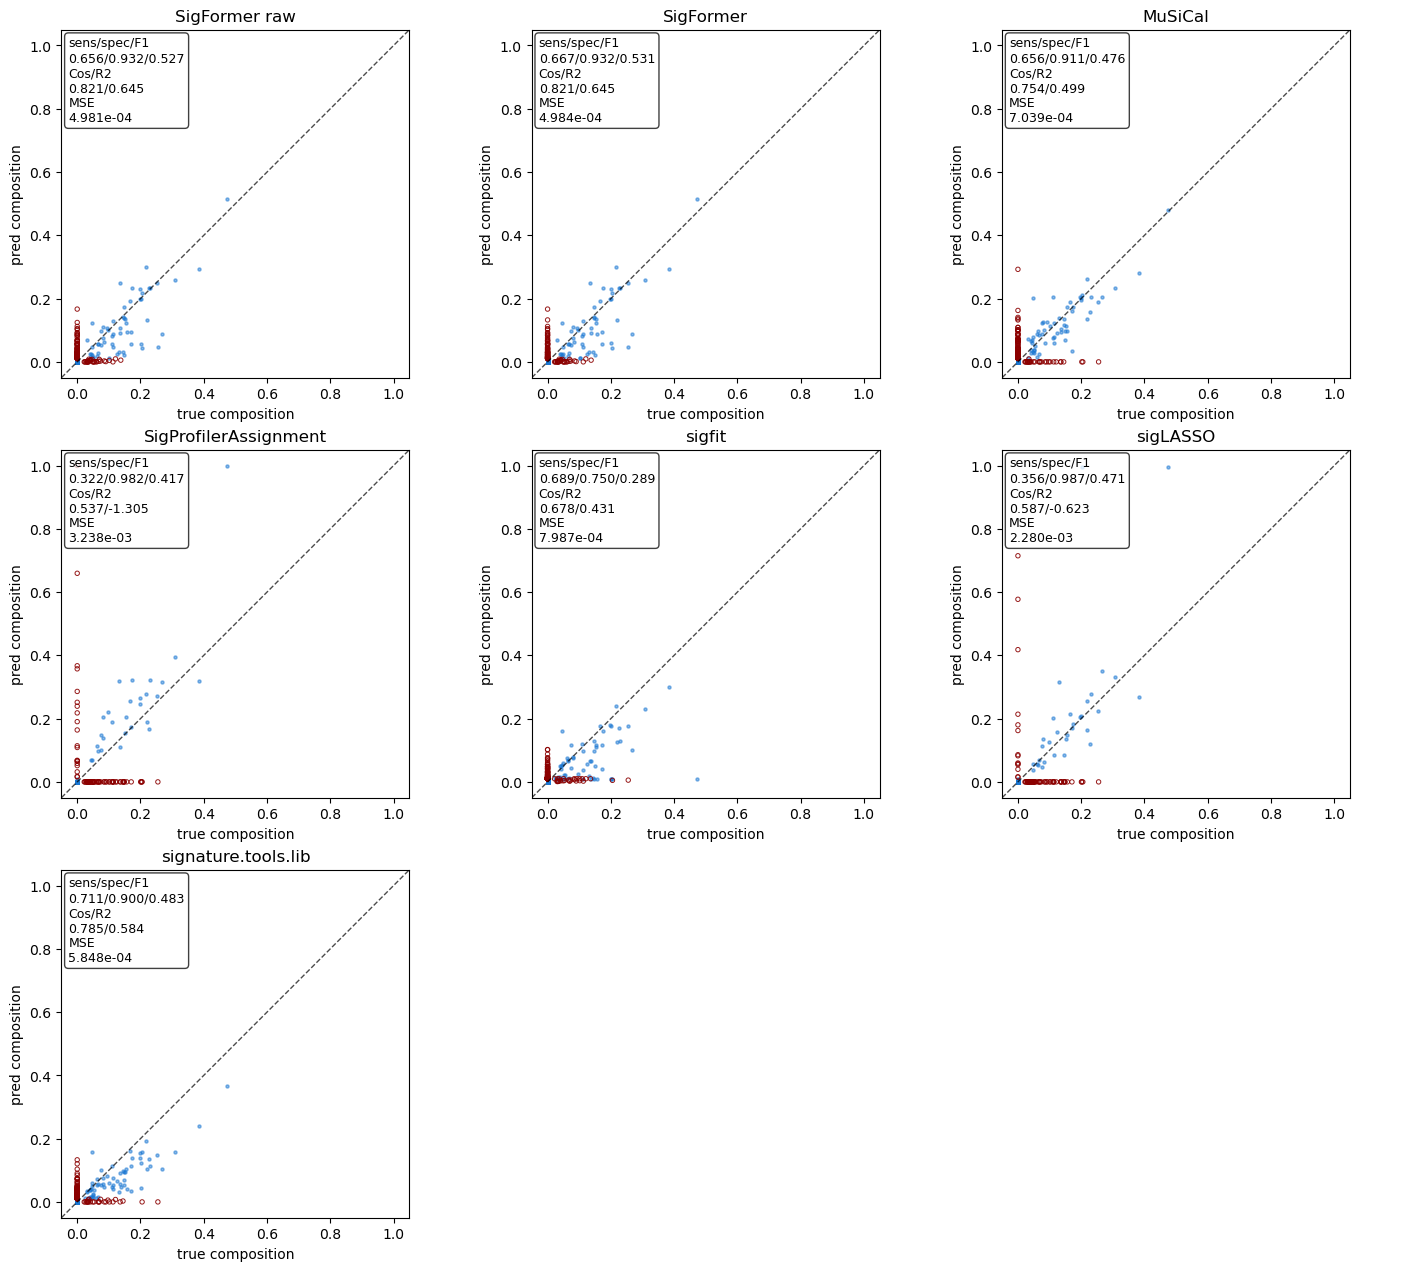

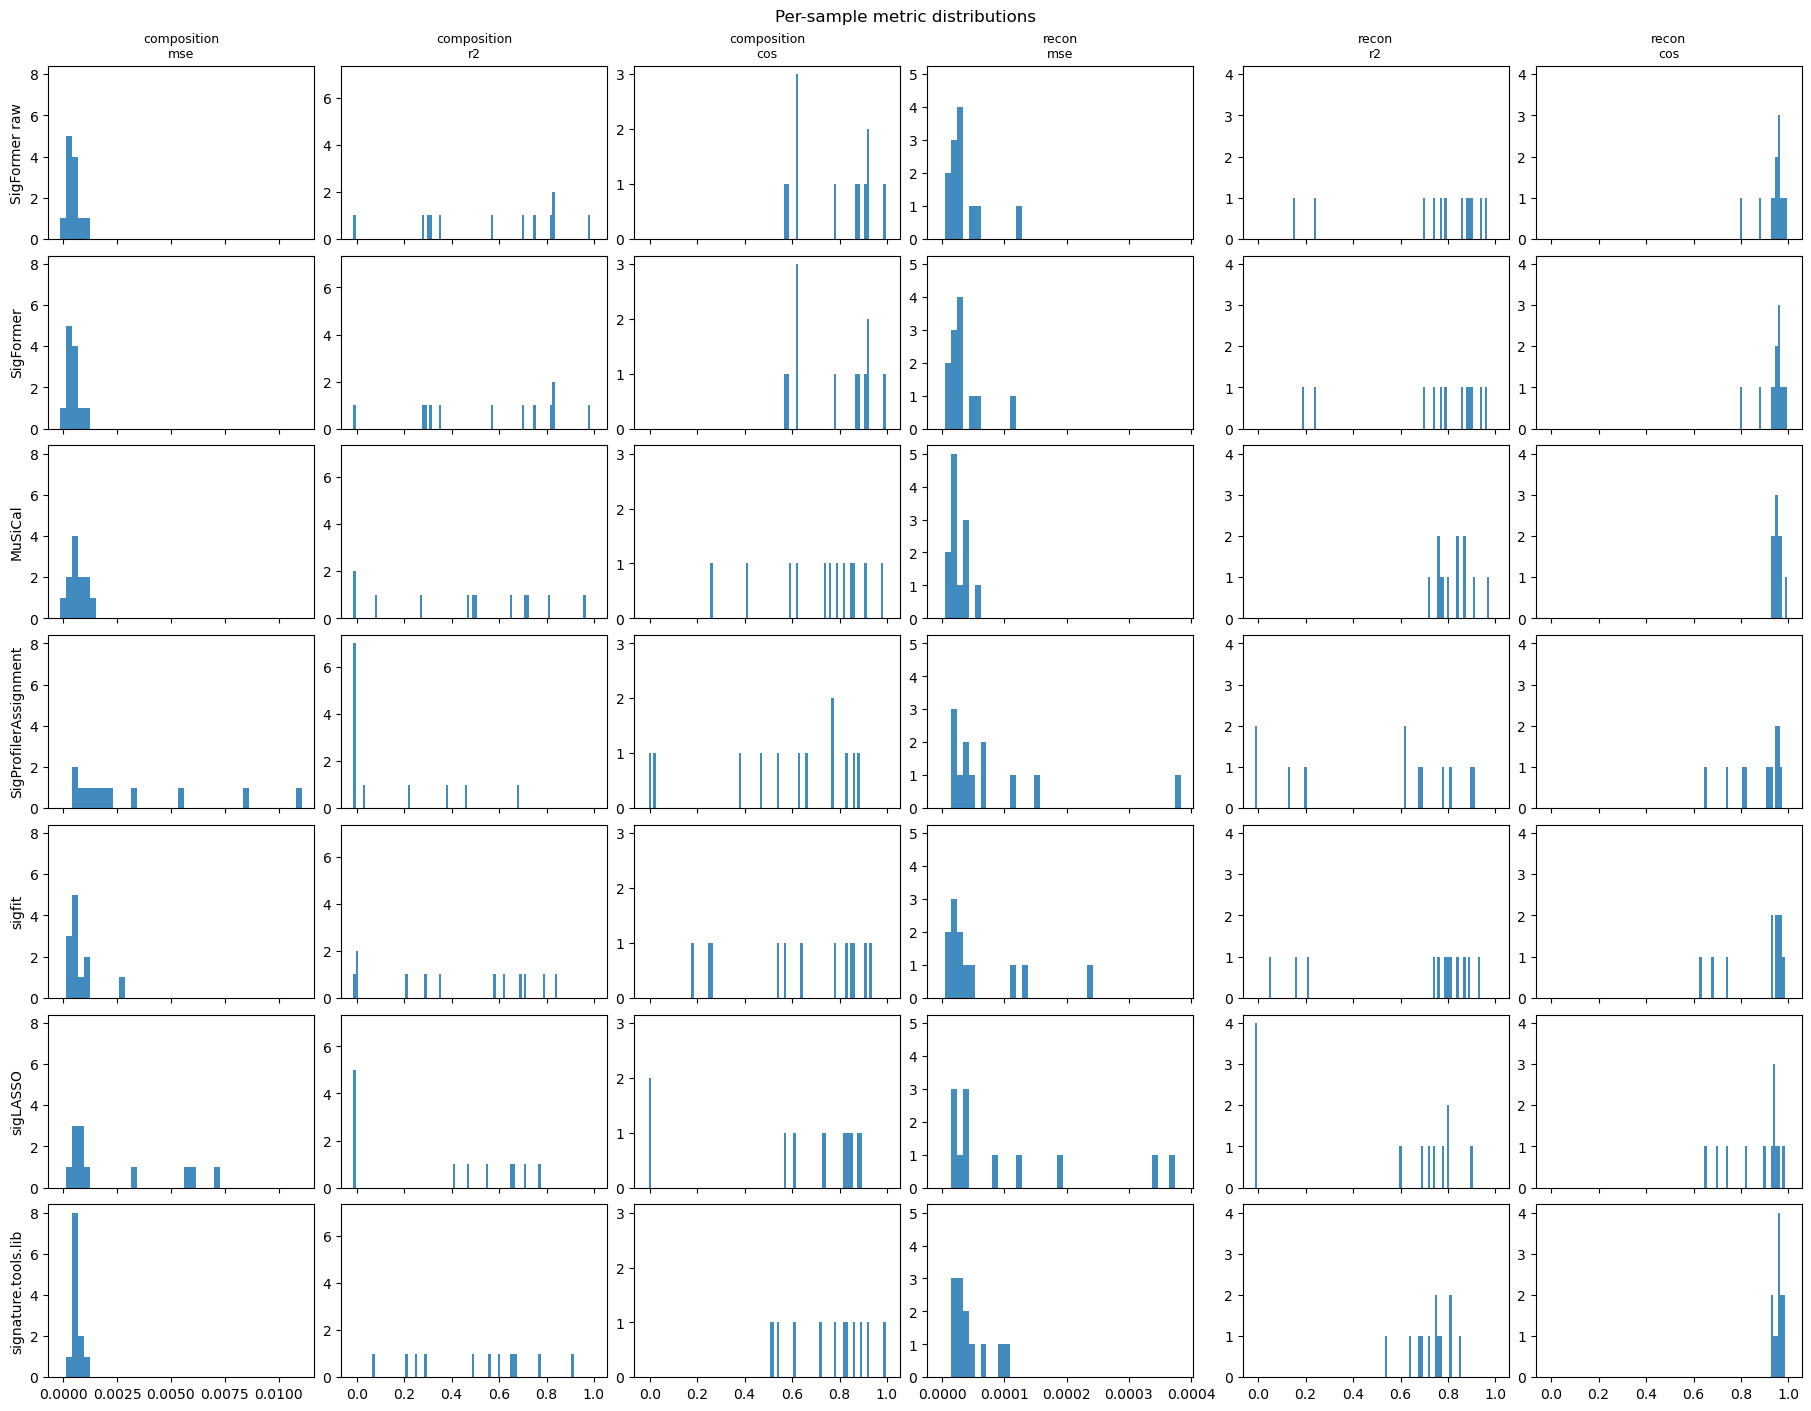

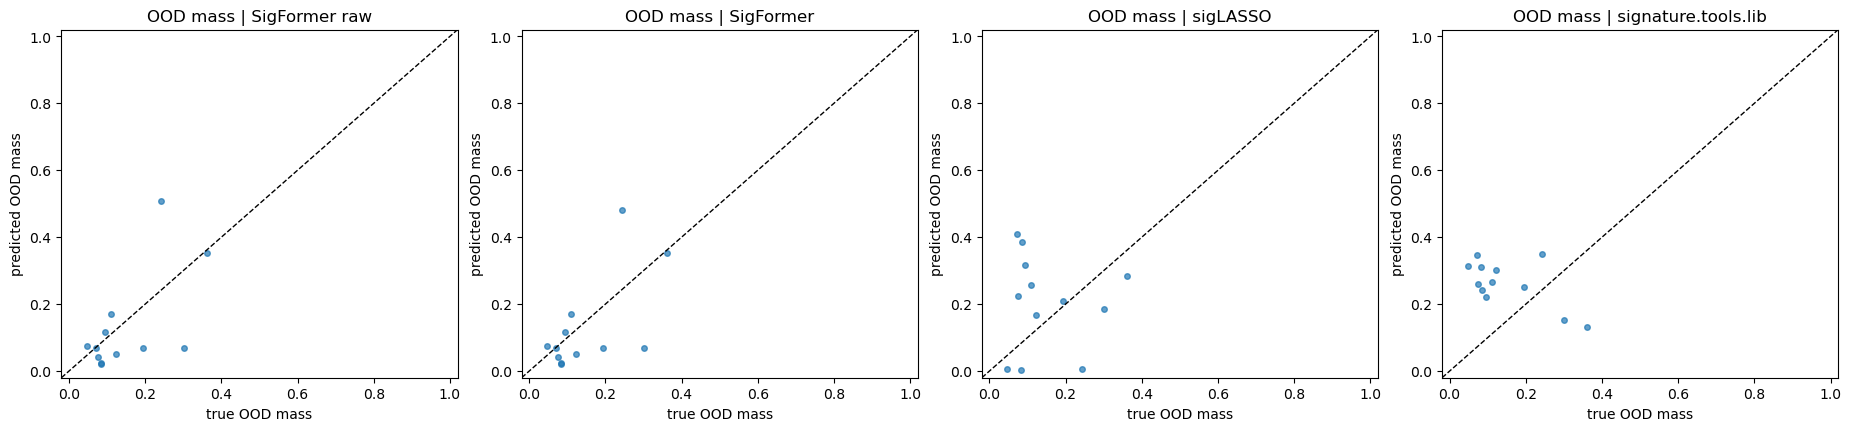

In [17]:
# Compute benchmark metrics and call each visualization function explicitly.

metrics_random_OOC, summary_random_OOC, compo_random_OOC, recon_random_OOC, ood_random_OOC, residual_random_OOC = bench.compute_benchmark_metrics(batch_random_OOC, results_random_OOC)
true_known_random_OOC = batch_random_OOC['Y_compo_true'].mask(batch_random_OOC['Y__OOD__mask'].astype(bool), 0.0)
fig, ax = bench.plot_profile_noise_qc(batch_random_OOC)
plt.show() ; plt.close(fig)
fig, axes = bench.plot_compo_scatter_grid(true_known_random_OOC, compo_random_OOC, methods=list(DICT_runner))
plt.show() ; plt.close(fig)
fig, axes = bench.plot_metric_hist_grid(metrics_random_OOC, methods=list(DICT_runner))
plt.show() ; plt.close(fig)
true_ood_random_OOC = batch_random_OOC['Y_compo_true'].where(batch_random_OOC['Y__OOD__mask'].astype(bool), 0.0).sum(1)
fig, axes = bench.plot_ood_scatter_grid(true_ood_random_OOC, ood_random_OOC, methods=[m for m in bench.OOD_PRED_METHODS if m in DICT_runner])
plt.show() ; plt.close(fig)

In [18]:
# Persist numerical outputs after visualization.

bench.save_benchmark_outputs(batch_random_OOC, results_random_OOC, out_random_OOC, timing=timing_random_OOC, make_plots=False, prefix='benchmark')
summary_random_OOC.to_csv(out_random_OOC / 'summary_preview.tsv', sep='\t', index=False)


---

## 3. titration_COSMIC

Each subsection has exactly four working cells: configuration, on-the-fly generation + inference, visualization, and result saving.

In [19]:
# Configure this benchmark condition.

cfg_titration_COSMIC = bench.MAKE_config_batch(mode='titration_COSMIC', BSize=12, REF_size={'COSMIC': 80, 'MOCK': 20}, depth_bin='1000-4000', noise_bin='0.90-0.95', compo_bin=1.0, titer_signature='SBS5', titer_nsmps=3, titer_steps=[0, 0.1, 0.3, 0.6])
out_titration_COSMIC = analysis.ensure_dir(NOTEBOOK_ROOT / 'titration_COSMIC')


In [20]:
# Generate the synthetic batch and run every selected method through the common timing wrapper.

batch_titration_COSMIC = bench.generate_benchmark_batch(bank, M_bank, cfg=cfg_titration_COSMIC, mode='titration_COSMIC', random_state=BASE_SEED + 2, batch_id='titration_COSMIC_demo')
mask_titration_COSMIC = bench.ref_mask_from_benchmark(batch_titration_COSMIC, full_reference=True)
results_titration_COSMIC, timing_titration_COSMIC = ({}, [])
for name, model in DICT_runner.items():
    bench.RUN_method_timed(name, model, batch_titration_COSMIC, mask_titration_COSMIC, results_titration_COSMIC, timing_titration_COSMIC, unit_label='titration_COSMIC', verbose=True)
timing_titration_COSMIC = pd.DataFrame(timing_titration_COSMIC)


[2026-08-12 03:28:35] titration_COSMIC | SigFormer raw start: n_samples=12
[2026-08-12 03:28:38] titration_COSMIC | SigFormer raw done: 2.62s, 218.13s / 1000 samples
[2026-08-12 03:28:38] titration_COSMIC | SigFormer start: n_samples=12
[2026-08-12 03:28:40] titration_COSMIC | SigFormer done: 2.03s, 169.46s / 1000 samples
[2026-08-12 03:28:40] titration_COSMIC | MuSiCal start: n_samples=12
[2026-08-12 03:29:04] titration_COSMIC | MuSiCal done: 24.14s, 2011.80s / 1000 samples
[2026-08-12 03:29:04] titration_COSMIC | SigProfilerAssignment start: n_samples=12
[2026-08-12 03:29:31] titration_COSMIC | SigProfilerAssignment done: 27.30s, 2274.85s / 1000 samples
[2026-08-12 03:29:31] titration_COSMIC | sigfit start: n_samples=12
[2026-08-12 03:30:58] titration_COSMIC | sigfit done: 76.16s, 6346.42s / 1000 samples
[2026-08-12 03:30:58] titration_COSMIC | sigLASSO start: n_samples=12
[2026-08-12 03:31:14] titration_COSMIC | sigLASSO done: 16.34s, 1361.88s / 1000 samples
[2026-08-12 03:31:14] ti

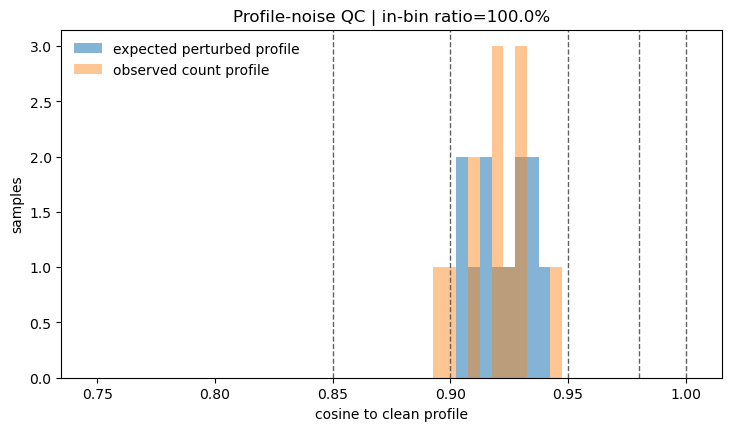

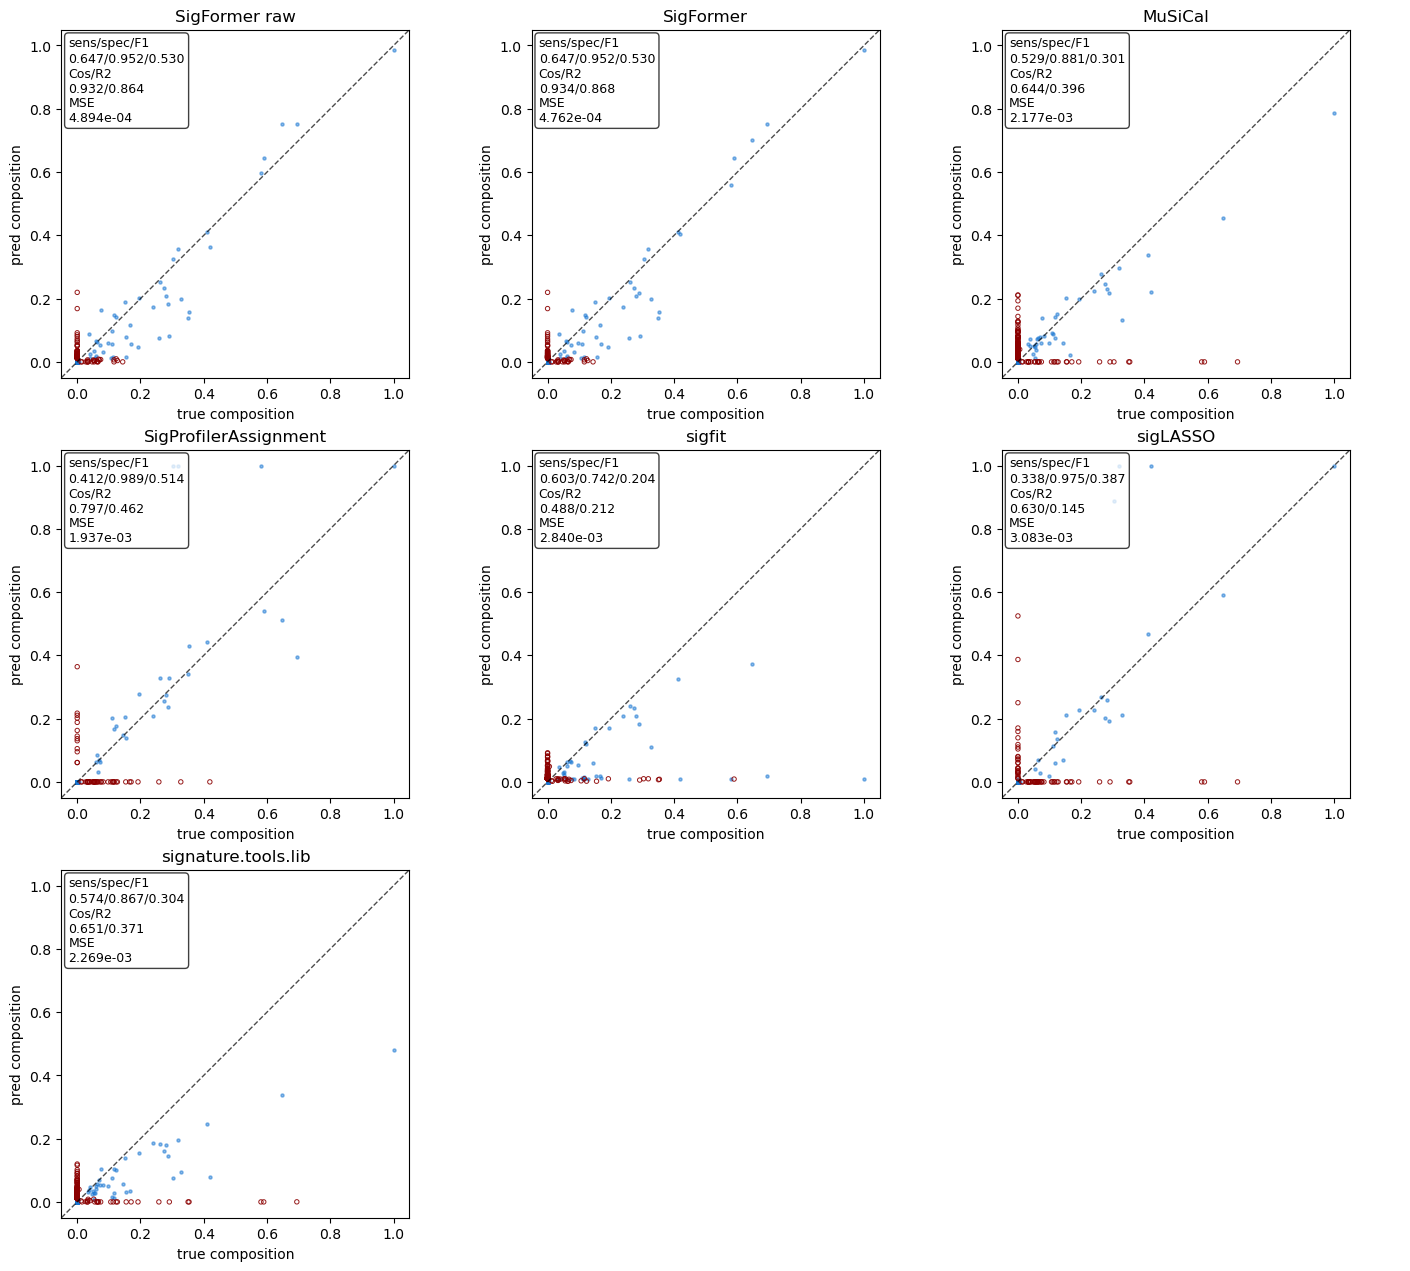

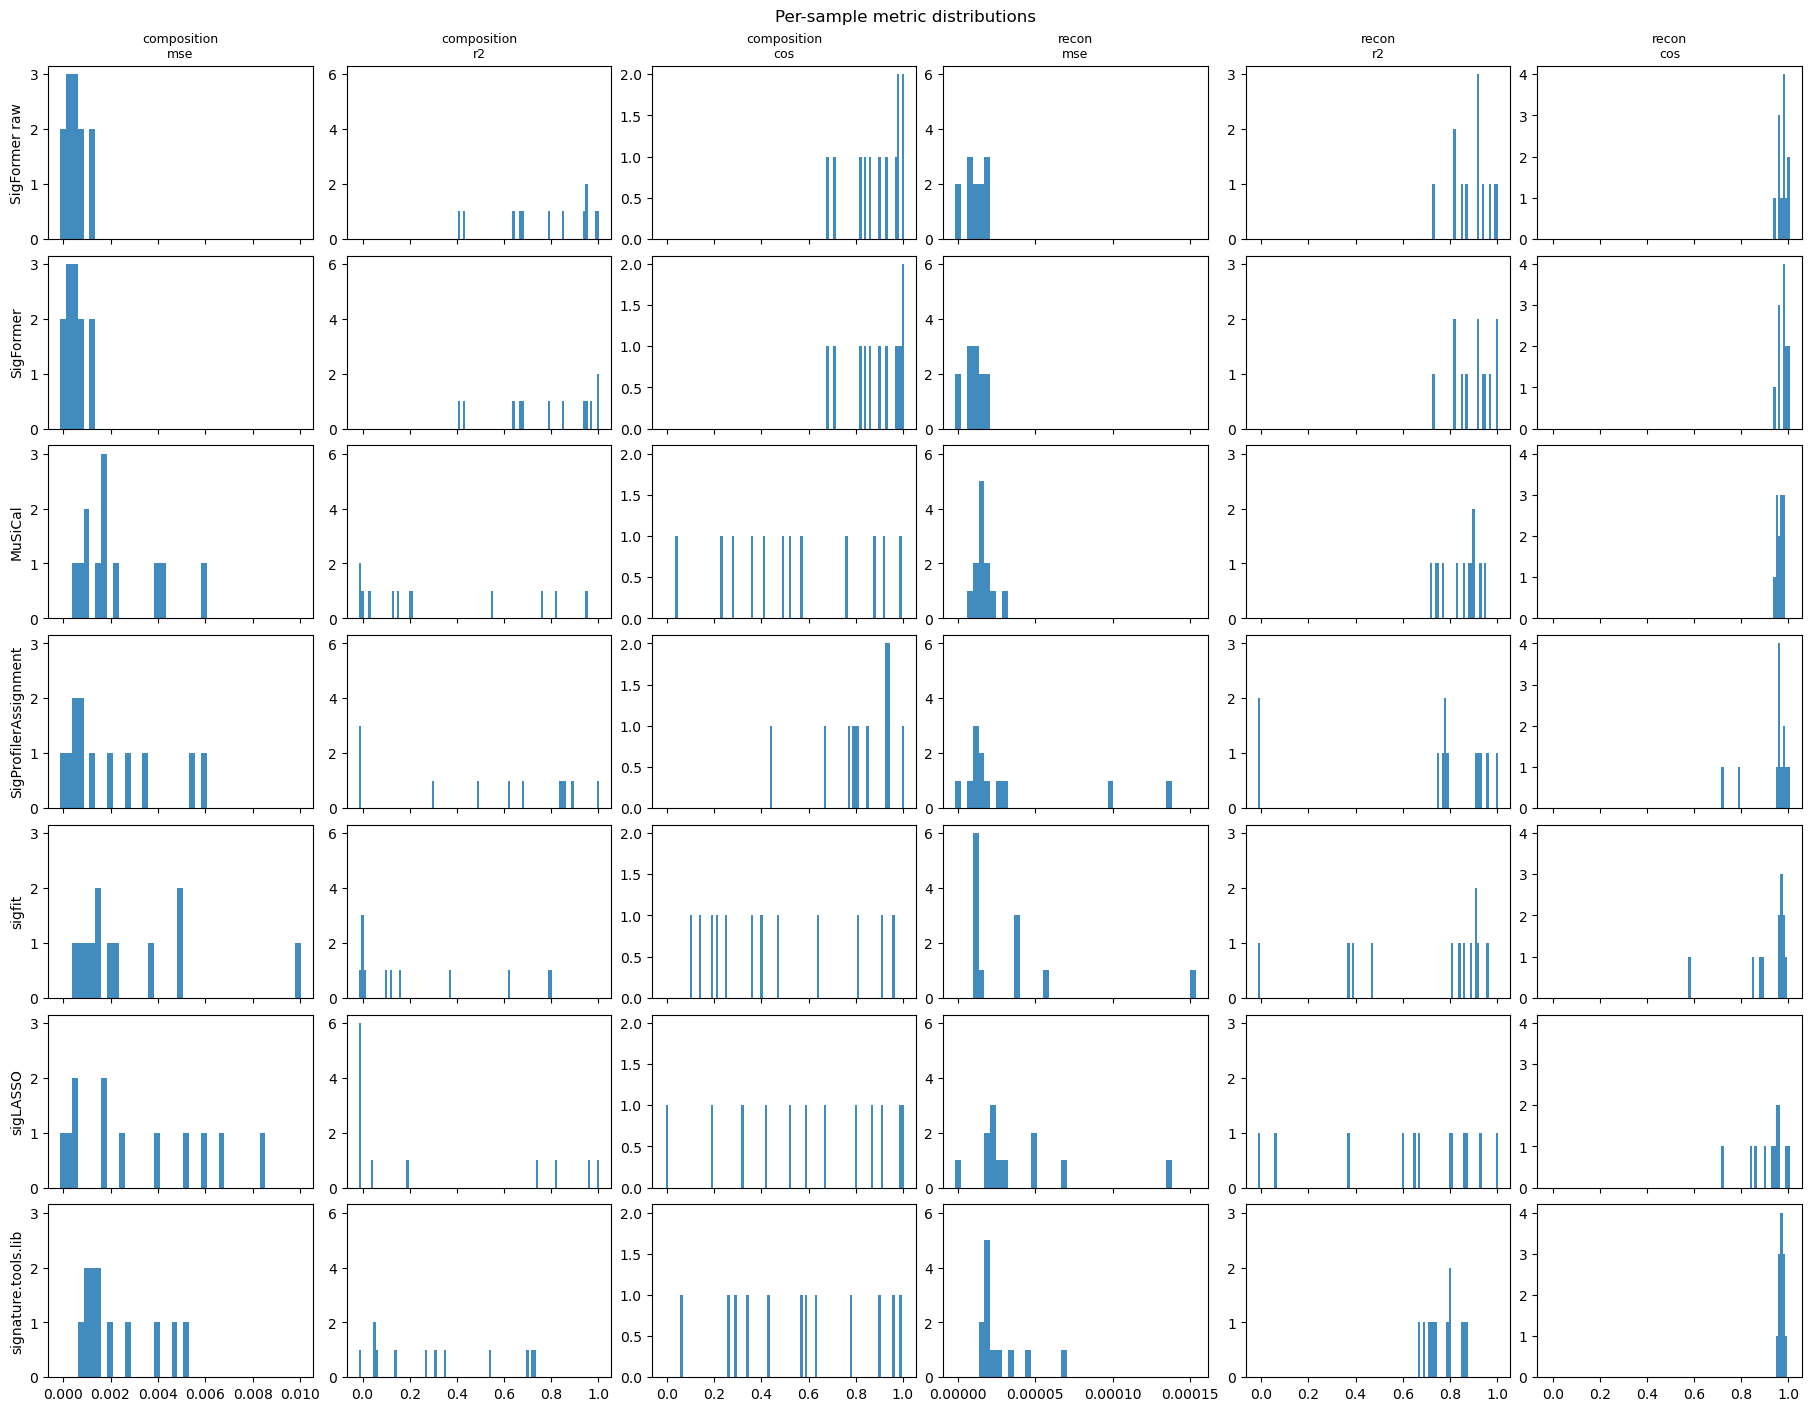

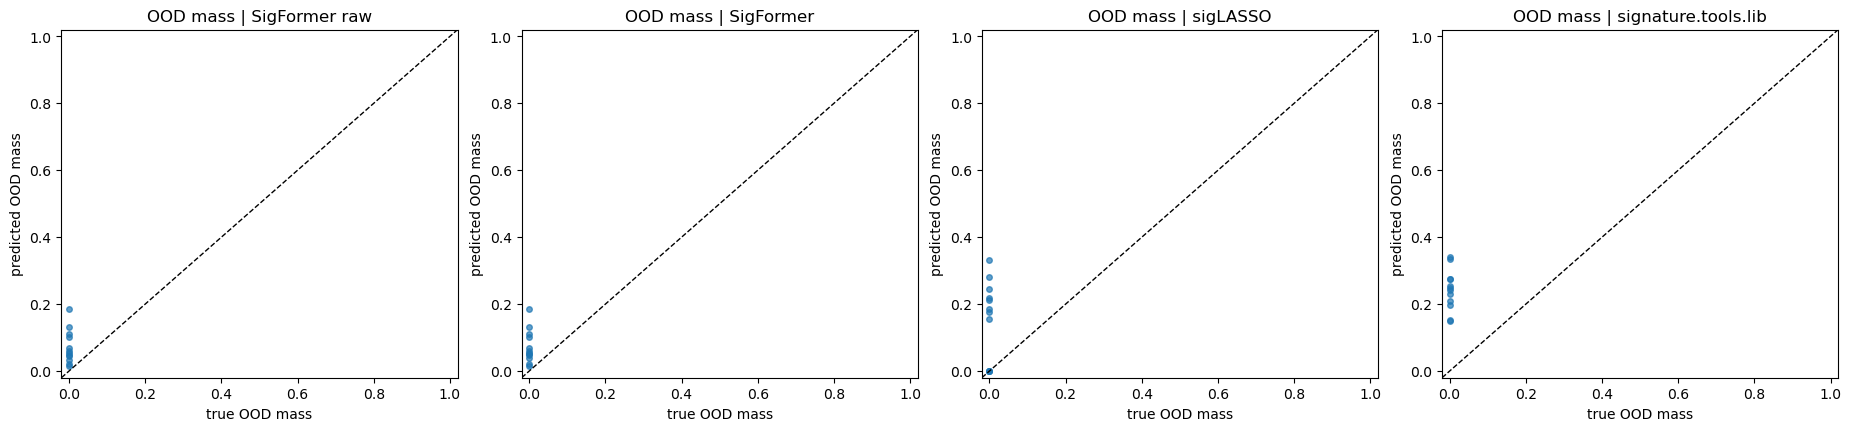

In [21]:
# Compute benchmark metrics and call each visualization function explicitly.

metrics_titration_COSMIC, summary_titration_COSMIC, compo_titration_COSMIC, recon_titration_COSMIC, ood_titration_COSMIC, residual_titration_COSMIC = bench.compute_benchmark_metrics(batch_titration_COSMIC, results_titration_COSMIC)
fig, ax = bench.plot_profile_noise_qc(batch_titration_COSMIC)
plt.show()
plt.close(fig)
fig, axes = bench.plot_compo_scatter_grid(batch_titration_COSMIC['Y_compo_true'], compo_titration_COSMIC, methods=list(DICT_runner))
plt.show()
plt.close(fig)
fig, axes = bench.plot_metric_hist_grid(metrics_titration_COSMIC, methods=list(DICT_runner))
plt.show()
plt.close(fig)
true_ood_titration_COSMIC = batch_titration_COSMIC['Y_compo_true'].where(batch_titration_COSMIC['Y__OOD__mask'].astype(bool), 0.0).sum(1)
fig, axes = bench.plot_ood_scatter_grid(true_ood_titration_COSMIC, ood_titration_COSMIC, methods=[m for m in bench.OOD_PRED_METHODS if m in DICT_runner])
plt.show()
plt.close(fig)


In [22]:
# Persist numerical outputs after visualization.

bench.save_benchmark_outputs(batch_titration_COSMIC, results_titration_COSMIC, out_titration_COSMIC, timing=timing_titration_COSMIC, make_plots=False, prefix='benchmark')
summary_titration_COSMIC.to_csv(out_titration_COSMIC / 'summary_preview.tsv', sep='\t', index=False)


---

## 4. titration_OOC

Each subsection has exactly four working cells: configuration, on-the-fly generation + inference, visualization, and result saving.

In [23]:
# Configure this benchmark condition.

cfg_titration_OOC = bench.MAKE_config_batch(mode='titration_OOC', BSize=12, REF_size={'COSMIC': 80, 'MOCK': 20}, depth_bin='1000-4000', noise_bin='0.90-0.95', compo_bin=1.0, titer_nsmps=3, titer_steps=[0, 0.1, 0.3, 0.6], denovo_source='leaveout_mock')
out_titration_OOC = analysis.ensure_dir(NOTEBOOK_ROOT / 'titration_OOC')
DICT_runner_OOC = {name: model for name, model in DICT_runner.items() if name in ['SgF_raw', 'SgF', 'sLS', 'stl']}


In [24]:
# Generate the synthetic batch and run every selected method through the common timing wrapper.

batch_titration_OOC = bench.generate_benchmark_batch(bank, M_bank, cfg=cfg_titration_OOC, mode='titration_OOC', random_state=BASE_SEED + 3, batch_id='titration_OOC_demo')
mask_titration_OOC = bench.ref_mask_from_benchmark(batch_titration_OOC, full_reference=True)
results_titration_OOC, timing_titration_OOC = ({}, [])
for name, model in DICT_runner_OOC.items():
    bench.RUN_method_timed(name, model, batch_titration_OOC, mask_titration_OOC, results_titration_OOC, timing_titration_OOC, unit_label='titration_OOC', verbose=True)
timing_titration_OOC = pd.DataFrame(timing_titration_OOC)


[2026-08-12 03:31:31] titration_OOC | SigFormer raw start: n_samples=12
[2026-08-12 03:31:31] titration_OOC | SigFormer raw done: 0.23s, 19.49s / 1000 samples
[2026-08-12 03:31:31] titration_OOC | SigFormer start: n_samples=12
[2026-08-12 03:31:32] titration_OOC | SigFormer done: 0.97s, 81.24s / 1000 samples
[2026-08-12 03:31:32] titration_OOC | sigLASSO start: n_samples=12
[2026-08-12 03:31:50] titration_OOC | sigLASSO done: 17.49s, 1457.68s / 1000 samples
[2026-08-12 03:31:50] titration_OOC | signature.tools.lib start: n_samples=12
[2026-08-12 03:31:57] titration_OOC | signature.tools.lib done: 6.72s, 559.73s / 1000 samples


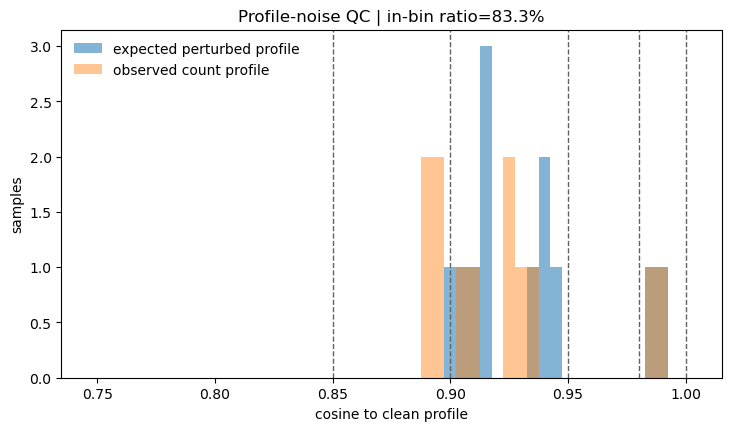

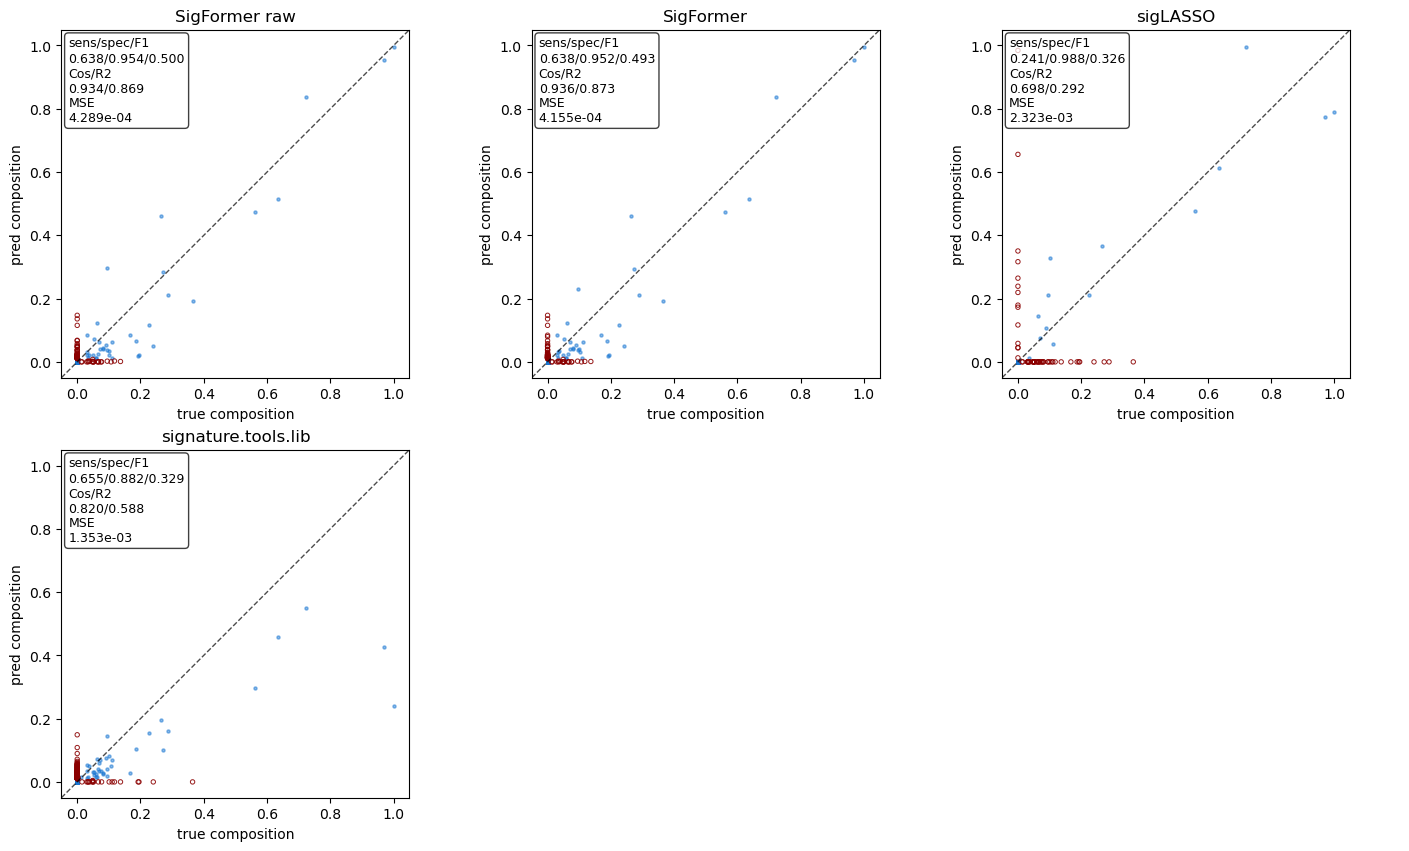

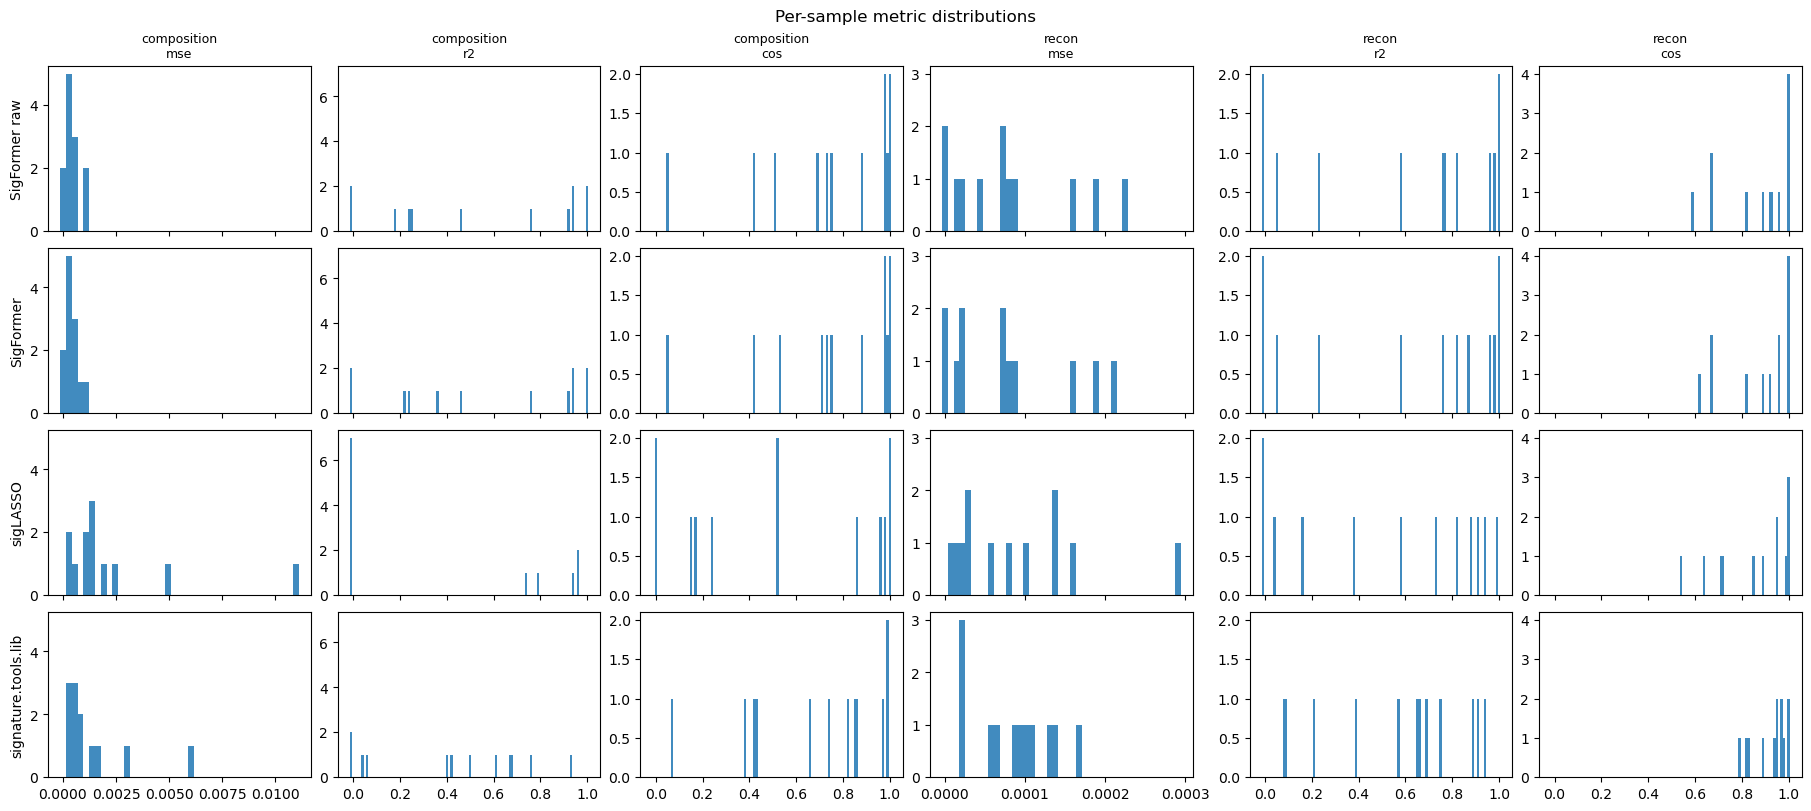

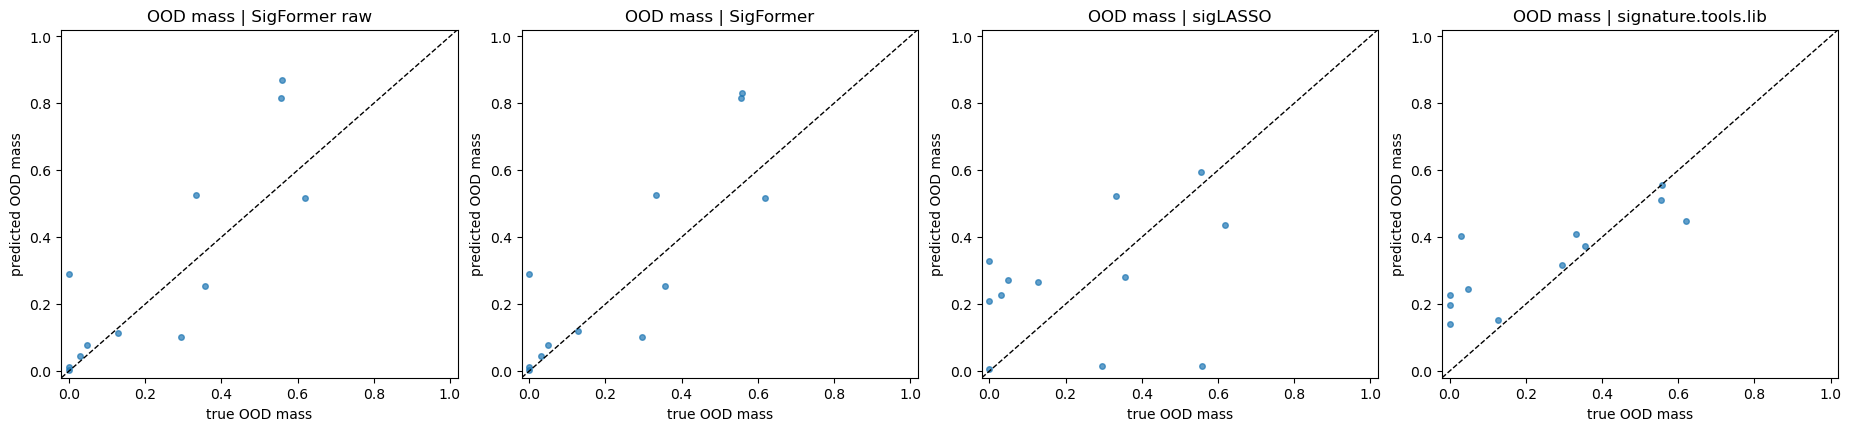

In [25]:
# Compute benchmark metrics and call each visualization function explicitly.

metrics_titration_OOC, summary_titration_OOC, compo_titration_OOC, recon_titration_OOC, ood_titration_OOC, residual_titration_OOC = bench.compute_benchmark_metrics(batch_titration_OOC, results_titration_OOC)
true_known_titration_OOC = batch_titration_OOC['Y_compo_true'].mask(batch_titration_OOC['Y__OOD__mask'].astype(bool), 0.0)
fig, ax = bench.plot_profile_noise_qc(batch_titration_OOC)
plt.show()
plt.close(fig)
fig, axes = bench.plot_compo_scatter_grid(true_known_titration_OOC, compo_titration_OOC, methods=list(DICT_runner_OOC))
plt.show()
plt.close(fig)
fig, axes = bench.plot_metric_hist_grid(metrics_titration_OOC, methods=list(DICT_runner_OOC))
plt.show()
plt.close(fig)
true_ood_titration_OOC = batch_titration_OOC['Y_compo_true'].where(batch_titration_OOC['Y__OOD__mask'].astype(bool), 0.0).sum(1)
fig, axes = bench.plot_ood_scatter_grid(true_ood_titration_OOC, ood_titration_OOC, methods=list(DICT_runner_OOC))
plt.show()
plt.close(fig)


In [26]:
# Persist numerical outputs after visualization.

bench.save_benchmark_outputs(batch_titration_OOC, results_titration_OOC, out_titration_OOC, timing=timing_titration_OOC, make_plots=False, prefix='benchmark')
summary_titration_OOC.to_csv(out_titration_OOC / 'summary_preview.tsv', sep='\t', index=False)


---

## 5. Batch CLI submission and checklist

Use this section for larger benchmark grids. The CLI uses the same wrappers, generator, and output schema as the interactive demonstration.

## 5. Batch benchmark CLI

The notebook builds a checklist, optionally submits commands, then reads completed result folders in bulk.

In [ ]:
CLI_ROOT = analysis.ensure_dir(NOTEBOOK_ROOT / 'cli_grid')
METHODS_BY_MODE = {'no_ood': bench.METHOD_ORDER, 'random': bench.METHOD_ORDER, 'cosmic_titration': bench.METHOD_ORDER, 'ood_titration': bench.OOD_PRED_METHODS}
cli_job_table = bench.make_job_table(CLI_ROOT, modes=['no_ood', 'random', 'cosmic_titration', 'ood_titration'], depth_bins=['1000-4000'], noise_bins=['0.90-0.95'], compo_bins=[1.0], active_bins=['1-3'], cosmic_signatures=['SBS5'], methods_by_mode=METHODS_BY_MODE)
commands = []
for _, row in cli_job_table.iterrows():
    command = f"{sys.executable} {SCRIPTS_DIR / 's09_bench_cli.py'}"
    command += f" --mode {row['mode']} --depth-bin {row['depth']} --noise-bin {row['noise']}"
    command += f" --compo-bin {row['compo']} --active-bin {row['active']}"
    command += " --n-samples 12 --n-batches 1 --titer-nsmps 3 --titer-steps 0,0.1,0.3,0.6"
    command += f" --methods {','.join(row['methods'])} --model-path {PATH_model}"
    command += f" --out-root {CLI_ROOT} --r-env {os.environ.get('CONDA_DEFAULT_ENV', '')}"
    commands.append(command)
cli_job_table['command'] = commands
cli_job_table.to_csv(CLI_ROOT / 'benchmark_checklist.tsv', sep='\t', index=False)
display(cli_job_table[['mode', 'condition_dir', 'methods', 'command']])

In [ ]:
SUBMIT = False
if SUBMIT:
    for command in cli_job_table['command']:
        subprocess.run(command, shell=True, check=True)


In [ ]:
status_all, summary_all, metrics_all, timing_all = bench.read_submitted_results(cli_job_table)
display(status_all)
display(summary_all.head())


In [ ]:
if len(summary_all):
    fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
    bench.plot_grouped_method_boxplot(summary_all, ax, condition_col='mode', metric='composition_r2_mean', method_order=bench.METHOD_ORDER)
    plt.show()
    plt.close(fig)
    for method in bench.METHOD_ORDER:
        if method not in set(summary_all['method']):
            continue
        fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
        bench.plot_metric_heatmap(summary_all, ax, x_col='noise', y_col='depth', method=method, metric='composition_r2_mean')
        plt.show()
        plt.close(fig)
